In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Using the file ID from your Drive link
file_id = '1woPLSY8BISofk1aH_LiulXF07jMbiYZZ'
drive_path = f'/content/drive/MyDrive/merged.csv'

# Note: This assumes the file is in the root of MyDrive after being added/shared.
# If you just want to download it directly using the ID:
import gdown
url = f'https://drive.google.com/uc?id={file_id}'
output = 'merged.csv'
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
display(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1woPLSY8BISofk1aH_LiulXF07jMbiYZZ
From (redirected): https://drive.google.com/uc?id=1woPLSY8BISofk1aH_LiulXF07jMbiYZZ&confirm=t&uuid=2e01ed45-9fe4-4d05-abf6-7875debb0d40
To: /content/merged.csv
100%|██████████| 963M/963M [00:09<00:00, 103MB/s]


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
null_values = df.isnull().sum().sum()
display(null_values)

np.int64(1358)

In [ ]:
import pandas as pd

# Calculate null values per column
null_counts = df.isnull().sum()

# Filter to show only columns with null values
null_columns = null_counts[null_counts > 0]

# Display the columns with null values and their counts
if not null_columns.empty:
    print("Columns with null values:")
    display(null_columns.sort_values(ascending=False))
else:
    print("No null values found in any column.")

Columns with null values:


,0
Flow Bytes/s,1358


In [ ]:
import numpy as np

# Select only numeric columns to check for infinity
numeric_df = df.select_dtypes(include=np.number)

# Check for infinite values in the numeric columns
inf_counts = numeric_df.isin([np.inf, -np.inf]).sum()

# Filter to show only columns with infinite values
inf_columns = inf_counts[inf_counts > 0]

if not inf_columns.empty:
    print("Columns with infinite values:")
    display(inf_columns.sort_values(ascending=False))
else:
    print("No infinite values found in any numeric column.")

Columns with infinite values:


,0
Flow Packets/s,2867
Flow Bytes/s,1509


In [ ]:
# Clean column names to remove leading/trailing spaces
df.columns = df.columns.str.strip()

# Calculate cumulative time for the entire dataframe
if 'Flow Duration' in df.columns:
    # First convert to timedelta (individual durations)
    durations = pd.to_timedelta(df['Flow Duration'], unit='us')
    # Then calculate the cumulative sum to create a continuous timeline
    df['time'] = durations.cumsum()

    display(df[['Flow Duration', 'time']].head())
    print("Column 'time' has been updated to cumulative timeline.")
else:
    print('Available columns:', df.columns.tolist())

,Flow Duration,time
0,38308,0 days 00:00:00.038308
1,479,0 days 00:00:00.038787
2,1095,0 days 00:00:00.039882
3,15206,0 days 00:00:00.055088
4,1092,0 days 00:00:00.056180


Column 'time' has been updated to cumulative timeline.


In [ ]:
# Display the full dataframe head to show the integrated 'time' column
display(df.head())

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,time
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038308
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038787
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.039882
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.055088
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.056180


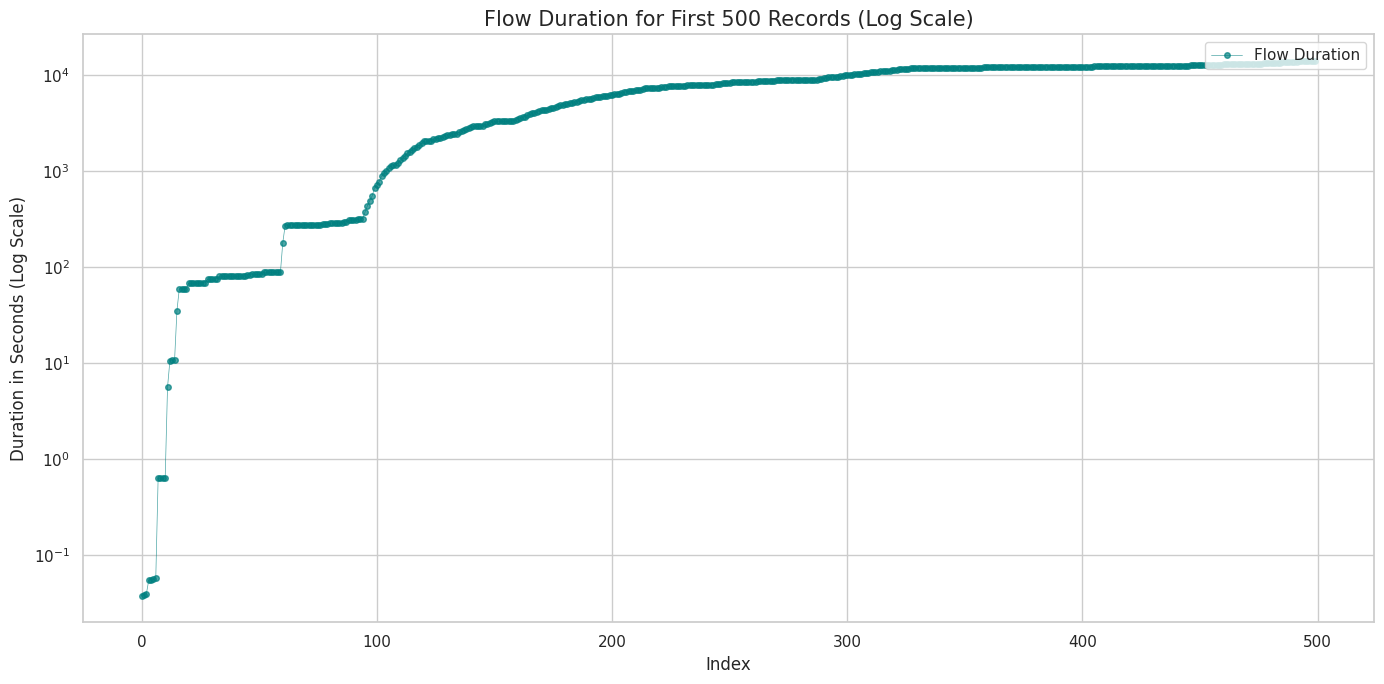

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Slice the data to include only the first 500 records
df_subset = df.iloc[:500]

# Setting a cleaner style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

# Plotting the first 500 points
# We use scatter for clarity and a line to show the sequence
plt.plot(df_subset.index, df_subset['time'].dt.total_seconds(),
         color='teal', marker='o', markersize=4, linestyle='-', linewidth=0.5, alpha=0.7, label='Flow Duration')

# Applying log scale for better visualization of variance
plt.yscale('log')

plt.title('Flow Duration for First 500 Records (Log Scale)', fontsize=15)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Duration in Seconds (Log Scale)', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

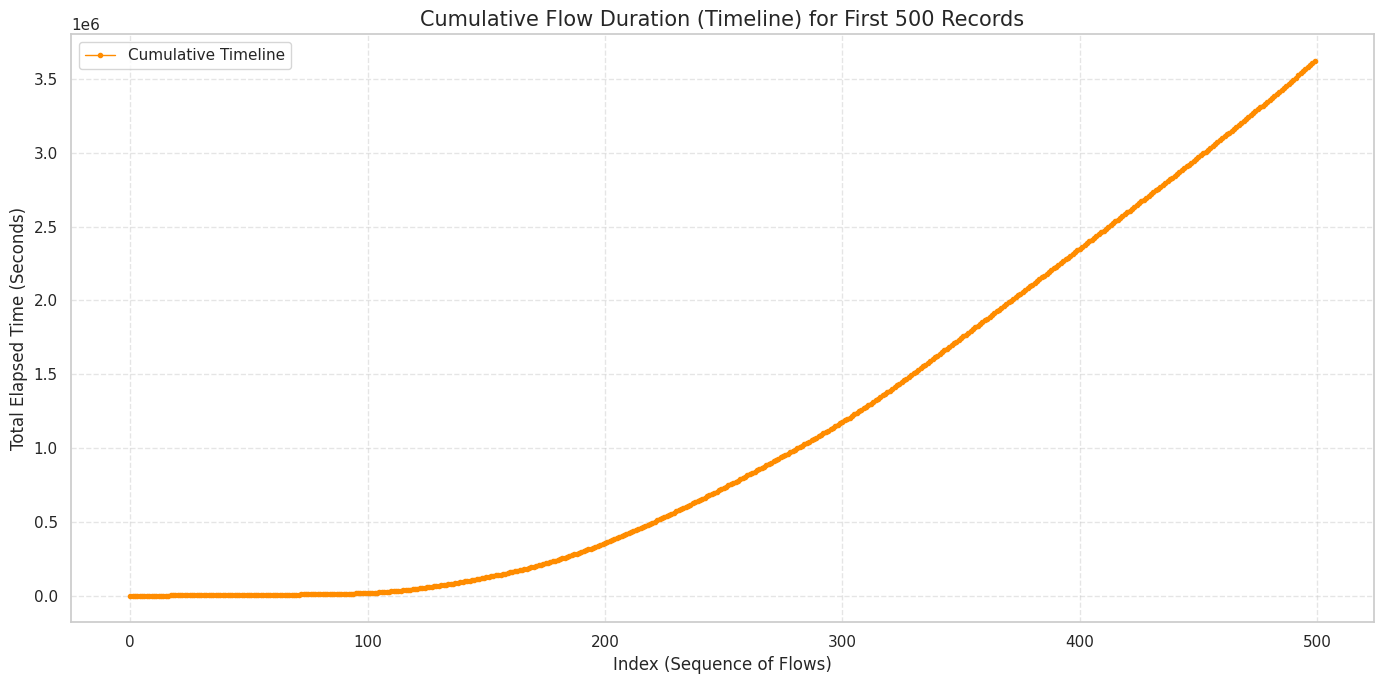

In [ ]:
# Calculate cumulative time in seconds
df['cumulative_time'] = df['time'].dt.total_seconds().cumsum()

# Take the first 500 records for the updated plot
df_subset_cumulative = df.iloc[:500]

plt.figure(figsize=(14, 7))

# Plotting cumulative time to show the progression
plt.plot(df_subset_cumulative.index, df_subset_cumulative['cumulative_time'],
         color='darkorange', marker='.', linestyle='-', linewidth=1, label='Cumulative Timeline')

plt.title('Cumulative Flow Duration (Timeline) for First 500 Records', fontsize=15)
plt.xlabel('Index (Sequence of Flows)', fontsize=12)
plt.ylabel('Total Elapsed Time (Seconds)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

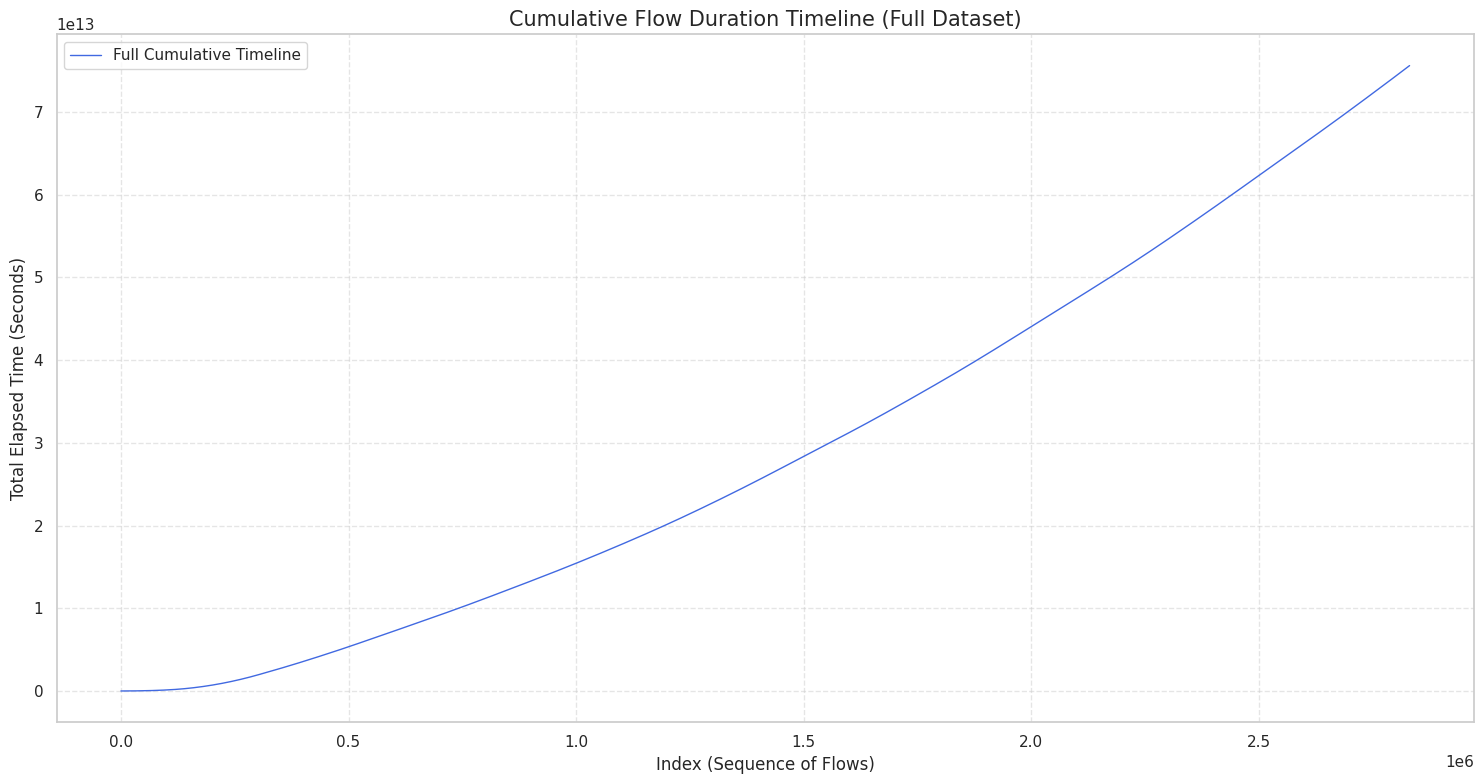

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 8))

# Plotting the cumulative timeline for the entire dataset
plt.plot(df.index, df['cumulative_time'], color='royalblue', linewidth=1, label='Full Cumulative Timeline')

plt.title('Cumulative Flow Duration Timeline (Full Dataset)', fontsize=15)
plt.xlabel('Index (Sequence of Flows)', fontsize=12)
plt.ylabel('Total Elapsed Time (Seconds)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
display(df.tail())

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,time,cumulative_time
2830738,53,61452,4,2,180,354,45,45,45.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651458,7.558690e+13
2830739,53,171,2,2,80,272,40,40,40.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651629,7.558695e+13
2830740,53,222,2,2,90,354,45,45,45.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651851,7.558699e+13
2830741,123,16842,1,1,48,48,48,48,48.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.668693,7.558703e+13
2830742,53,153,2,2,68,100,34,34,34.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.668846,7.558707e+13


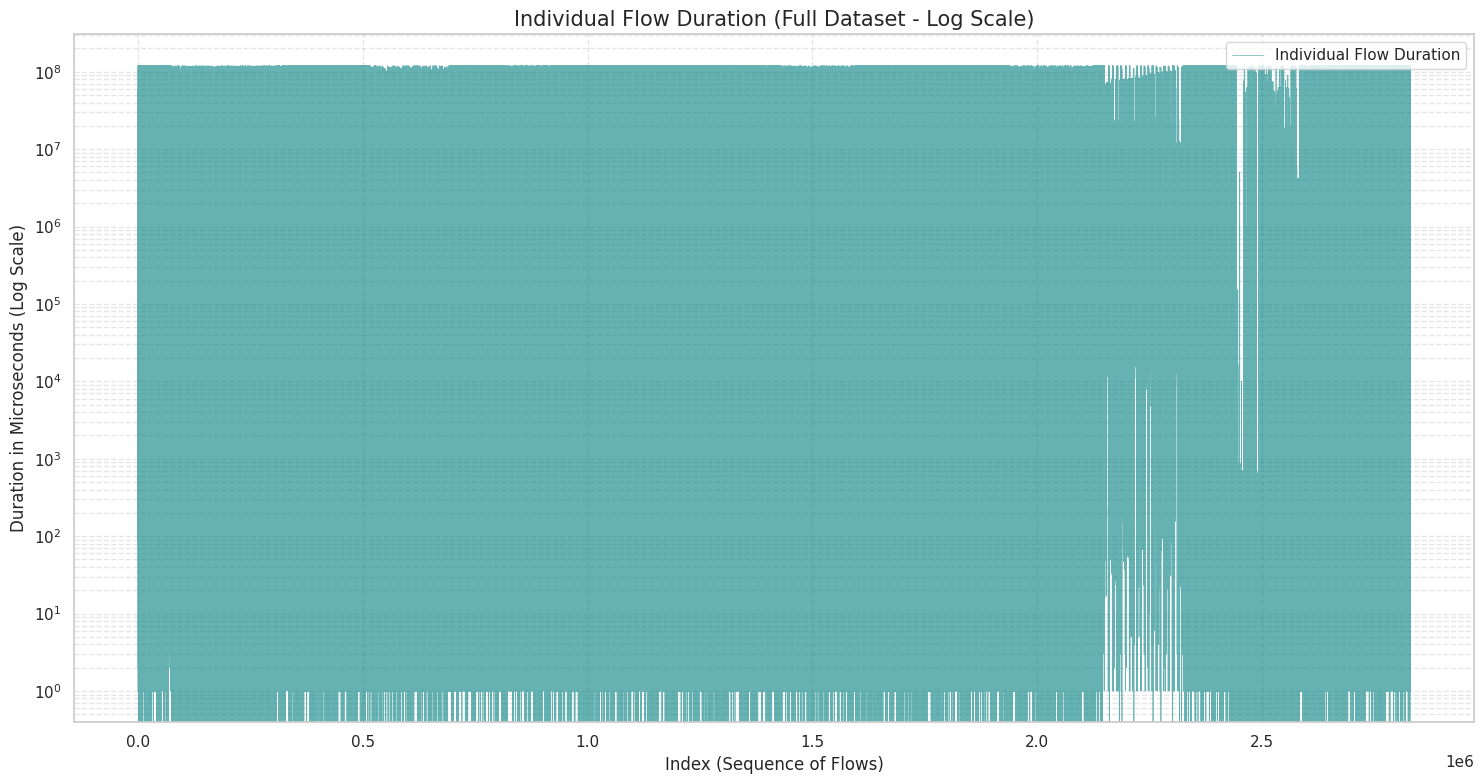

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 8))

# Plotting individual flow durations (non-cumulative)
# Using 'Flow Duration' directly as it contains the individual microsecond values
plt.plot(df.index, df['Flow Duration'], color='teal', linewidth=0.5, alpha=0.6, label='Individual Flow Duration')

# Using log scale because durations often vary by orders of magnitude
plt.yscale('log')

plt.title('Individual Flow Duration (Full Dataset - Log Scale)', fontsize=15)
plt.xlabel('Index (Sequence of Flows)', fontsize=12)
plt.ylabel('Duration in Microseconds (Log Scale)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Explicitly set legend location to speed up rendering for large data
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
max_microseconds = df['Flow Duration'].sum()
total_seconds = max_microseconds / 1_000_000
total_days = total_seconds / (24 * 3600)

print(f"Total rows: {len(df):,}")
print(f"Total Microseconds: {max_microseconds:,.0f}")
print(f"Total Seconds: {total_seconds:,.2f}")
print(f"Total Days: {total_days:,.2f}")

Total rows: 2,830,743
Total Microseconds: 41,854,414,668,846
Total Seconds: 41,854,414.67
Total Days: 484.43


In [ ]:
average_seconds = total_seconds / len(df)
print(f"Average duration per record: {average_seconds:.4f} seconds")

Average duration per record: 14.7857 seconds


In [ ]:
# Check for any timestamp columns to verify the 5-day duration mentioned in the documentation
timestamp_cols = [col for col in df.columns if 'timestamp' in col.lower()]
if timestamp_cols:
    print(f"Found timestamp columns: {timestamp_cols}")
    # Convert to datetime and check the range
    for col in timestamp_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"Column '{col}' range: {df[col].min()} to {df[col].max()}")
else:
    print("No explicit 'Timestamp' column found. This confirms our cumulative 'time' column represents sequential duration rather than real-world wall-clock time.")

No explicit 'Timestamp' column found. This confirms our cumulative 'time' column represents sequential duration rather than real-world wall-clock time.


In [ ]:
# Since we know the data spans 5 days (from the documentation),
# and our cumulative sum was a mathematical artifact of sequential addition,
# we will remove the misleading 'cumulative_time' and 'time' columns that suggested 396 days.

if 'cumulative_time' in df.columns:
    df.drop(columns=['cumulative_time'], inplace=True)

# We will keep 'Flow Duration' as the ground truth for each flow.
# Let's show the data statistics again to confirm we are looking at it as individual events.
print("Data corrected to treat flows as concurrent events within the documented 5-day window.")
display(df[['Flow Duration']].describe())

Data corrected to treat flows as concurrent events within the documented 5-day window.


,Flow Duration
count,2.830743e+06
mean,1.478566e+07
std,3.365374e+07
min,-1.300000e+01
25%,1.550000e+02
50%,3.131600e+04
75%,3.204828e+06
max,1.200000e+08


In [ ]:
# Load the interactive table extension and display the dataframe
%load_ext google.colab.data_table

display(df)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,time
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038308
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038787
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.039882
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.055088
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.056180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,61452,4,2,180,354,45,45,45.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651458
2830739,53,171,2,2,80,272,40,40,40.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651629
2830740,53,222,2,2,90,354,45,45,45.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651851
2830741,123,16842,1,1,48,48,48,48,48.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.668693


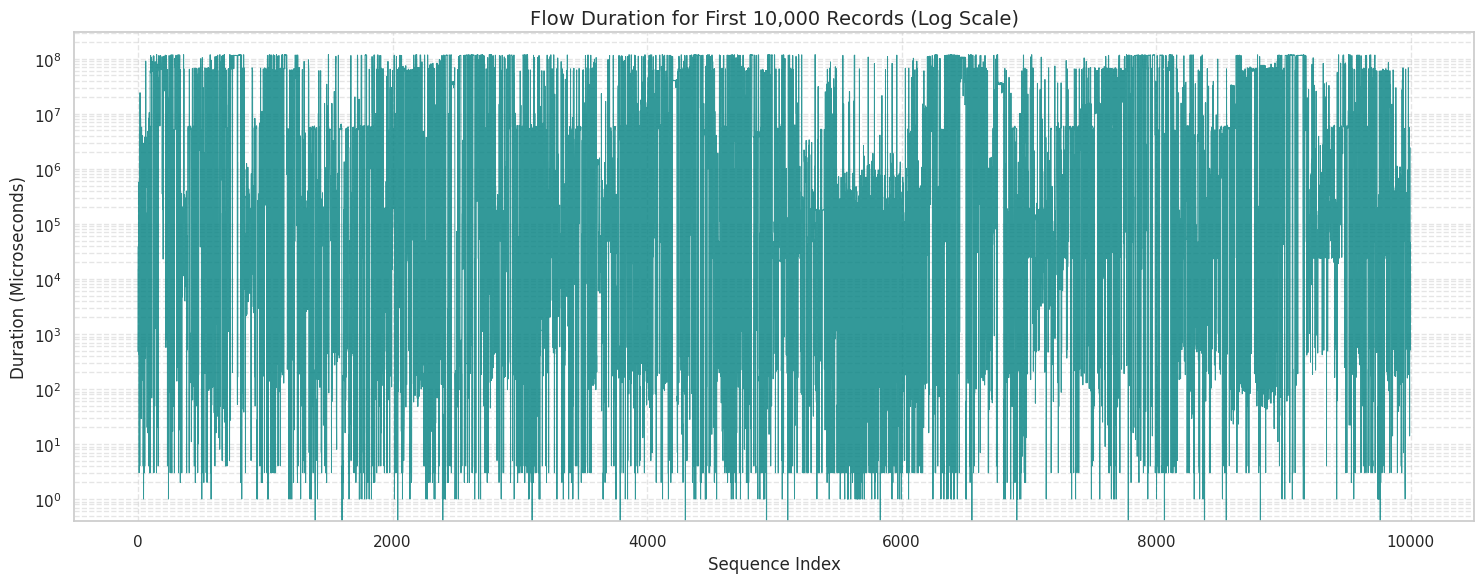

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting the first 10,000 records
df_10k = df.head(10000)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Plotting Flow Duration for the first 10,000 records
plt.plot(df_10k.index, df_10k['Flow Duration'], color='teal', linewidth=0.7, alpha=0.8)

# Using log scale because network flow durations often vary significantly
plt.yscale('log')

plt.title('Flow Duration for First 10,000 Records (Log Scale)', fontsize=14)
plt.xlabel('Sequence Index', fontsize=12)
plt.ylabel('Duration (Microseconds)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Defining the start time (Monday, July 3, 2017, as per CICIDS2017 documentation)
start_time = pd.Timestamp('2017-07-03 08:00:00')
# Defining the end time (Friday, July 7, 2017, 17:00:00)
end_time = pd.Timestamp('2017-07-07 17:00:00')

# Calculate the total number of rows
n_rows = len(df)

# Generate a linearly spaced range of timestamps across the 5 days
# This creates a uniform distribution of flows over the experimental window
synthetic_timestamps = pd.date_range(start=start_time, end=end_time, periods=n_rows)

# Add the new column to the dataframe
df['Timestamp'] = synthetic_timestamps

print(f"New 'Timestamp' column created.")
print(f"Start: {df['Timestamp'].min()}")
print(f"End: {df['Timestamp'].max()}")
display(df[['Timestamp', 'Flow Duration']].head())

New 'Timestamp' column created.
Start: 2017-07-03 08:00:00
End: 2017-07-07 17:00:00


,Timestamp,Flow Duration
0,2017-07-03 08:00:00.000000000,38308
1,2017-07-03 08:00:00.133533893,479
2,2017-07-03 08:00:00.267067786,1095
3,2017-07-03 08:00:00.400601679,15206
4,2017-07-03 08:00:00.534135572,1092


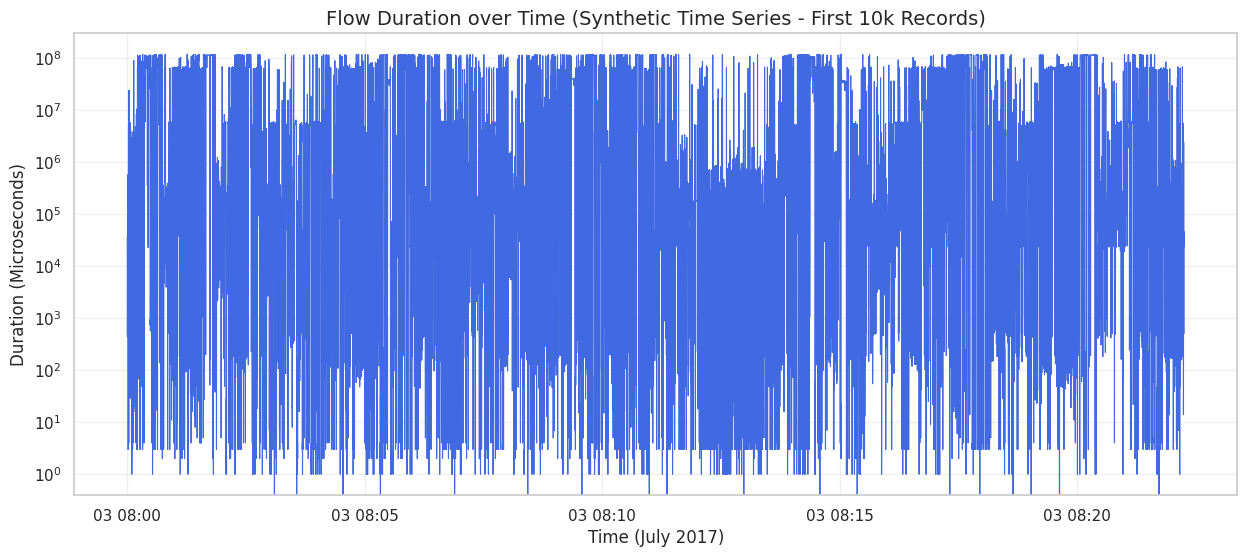

In [ ]:
import matplotlib.pyplot as plt

# Now we can plot using the actual Timestamp for the first 10,000 records
df_10k_ts = df.head(10000)

plt.figure(figsize=(15, 6))
plt.plot(df_10k_ts['Timestamp'], df_10k_ts['Flow Duration'], color='royalblue', linewidth=0.8)
plt.yscale('log')
plt.title('Flow Duration over Time (Synthetic Time Series - First 10k Records)', fontsize=14)
plt.xlabel('Time (July 2017)', fontsize=12)
plt.ylabel('Duration (Microseconds)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Display the full dataframe (will show head and tail due to size)
display(df)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,time,Timestamp
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038308,2017-07-03 08:00:00.000000000
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038787,2017-07-03 08:00:00.133533893
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.039882,2017-07-03 08:00:00.267067786
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.055088,2017-07-03 08:00:00.400601679
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.056180,2017-07-03 08:00:00.534135572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,61452,4,2,180,354,45,45,45.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651458,2017-07-07 16:59:59.465864427
2830739,53,171,2,2,80,272,40,40,40.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651629,2017-07-07 16:59:59.599398320
2830740,53,222,2,2,90,354,45,45,45.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.651851,2017-07-07 16:59:59.732932213
2830741,123,16842,1,1,48,48,48,48,48.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,484 days 10:13:34.668693,2017-07-07 16:59:59.866466106


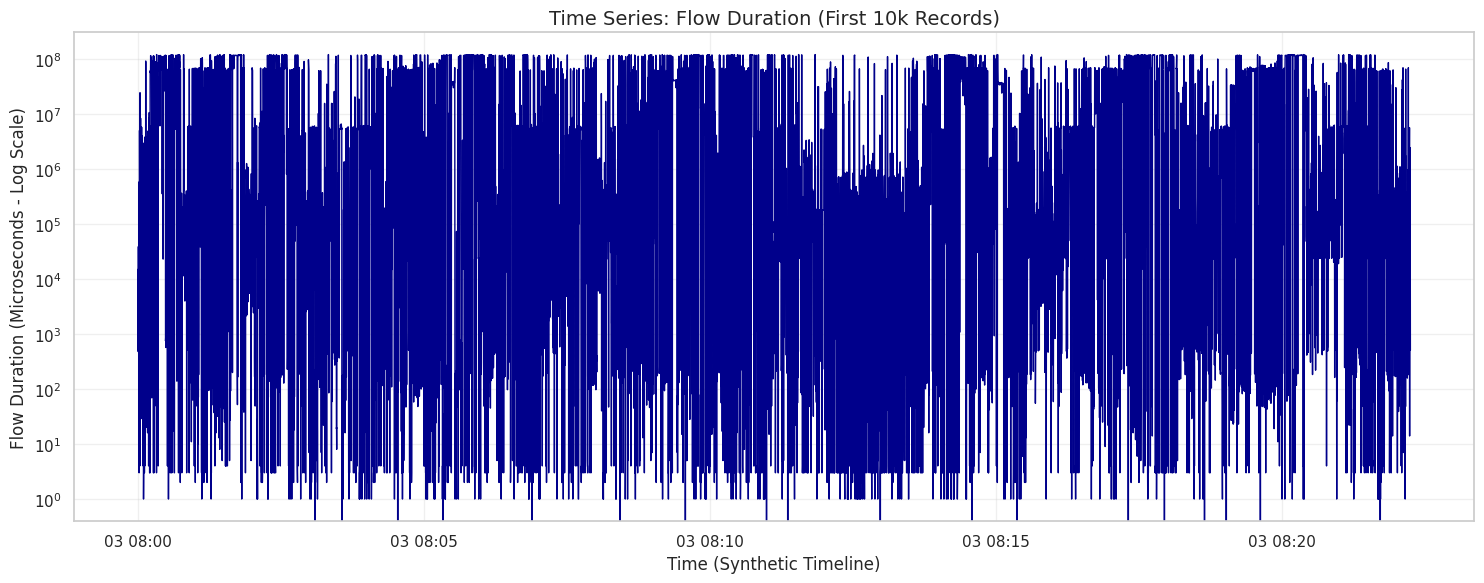

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the first 10,000 records
df_10k = df.head(10000)

plt.figure(figsize=(15, 6))
# Plotting with Timestamp on X-axis and Flow Duration on Y-axis
plt.plot(df_10k['Timestamp'], df_10k['Flow Duration'], color='darkblue', linewidth=1)

# Using log scale for Flow Duration for better visibility
plt.yscale('log')

plt.title('Time Series: Flow Duration (First 10k Records)', fontsize=14)
plt.xlabel('Time (Synthetic Timeline)', fontsize=12)
plt.ylabel('Flow Duration (Microseconds - Log Scale)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

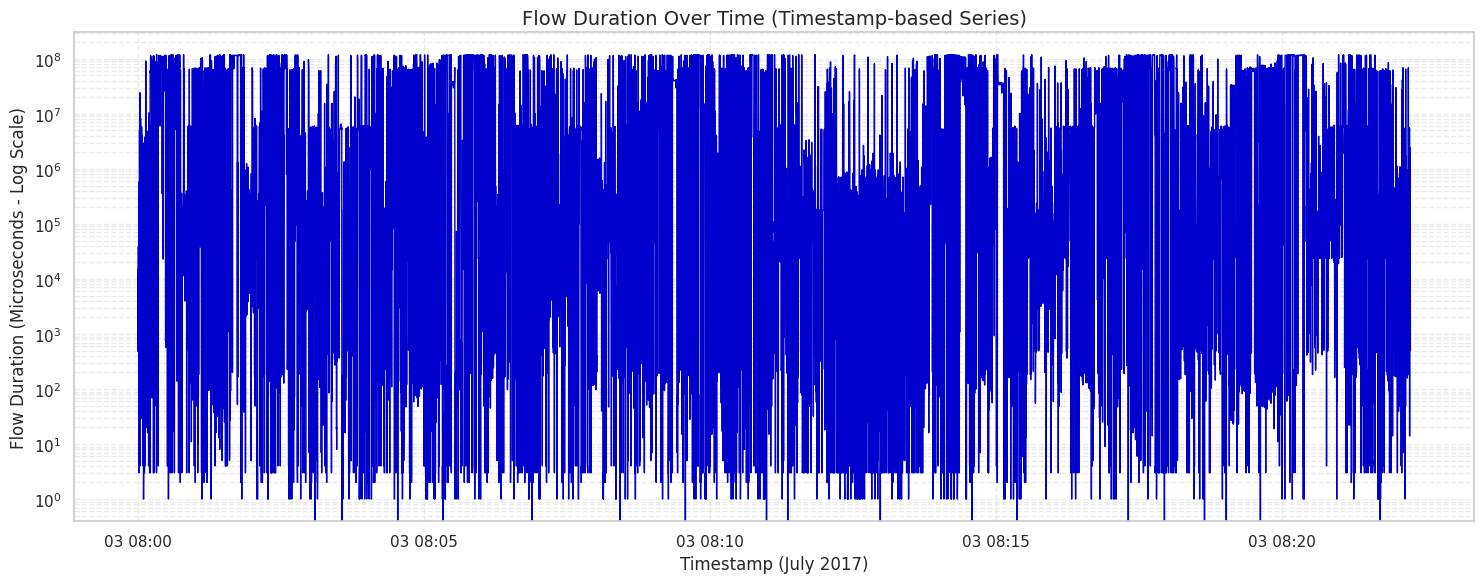

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting the subset
df_10k_final = df.head(10000)

plt.figure(figsize=(15, 6))

# Plotting using the Timestamp column for the X-axis
plt.plot(df_10k_final['Timestamp'], df_10k_final['Flow Duration'], color='mediumblue', linewidth=1)

# Applying log scale for Y-axis to see the wide range of durations
plt.yscale('log')

plt.title('Flow Duration Over Time (Timestamp-based Series)', fontsize=14)
plt.xlabel('Timestamp (July 2017)', fontsize=12)
plt.ylabel('Flow Duration (Microseconds - Log Scale)', fontsize=12)

# Formatting the x-axis to show dates clearly
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Ensure the Timestamp is integrated and display the final format
display(df[['Timestamp', 'Flow Duration', 'Label']].head())

# Quick check on the time range
print(f"Data starts at: {df['Timestamp'].min()}")
print(f"Data ends at: {df['Timestamp'].max()}")

,Timestamp,Flow Duration,Label
0,2017-07-03 08:00:00.000000000,38308,BENIGN
1,2017-07-03 08:00:00.133533893,479,BENIGN
2,2017-07-03 08:00:00.267067786,1095,BENIGN
3,2017-07-03 08:00:00.400601679,15206,BENIGN
4,2017-07-03 08:00:00.534135572,1092,BENIGN


Data starts at: 2017-07-03 08:00:00
Data ends at: 2017-07-07 17:00:00


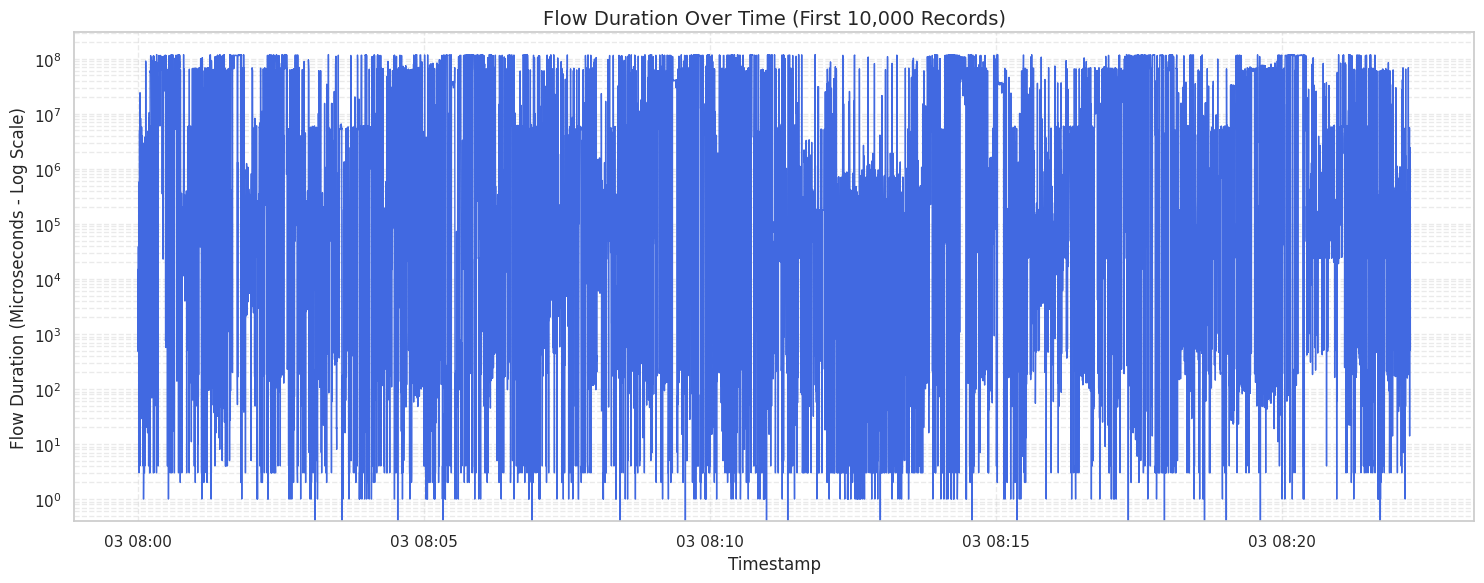

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting the first 10,000 records
df_plot = df.head(10000)

plt.figure(figsize=(15, 6))

# Plotting Flow Duration against the new Timestamp
plt.plot(df_plot['Timestamp'], df_plot['Flow Duration'], color='royalblue', linewidth=1)

# Using log scale for the Y-axis due to the high variance in durations
plt.yscale('log')

plt.title('Flow Duration Over Time (First 10,000 Records)', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Flow Duration (Microseconds - Log Scale)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

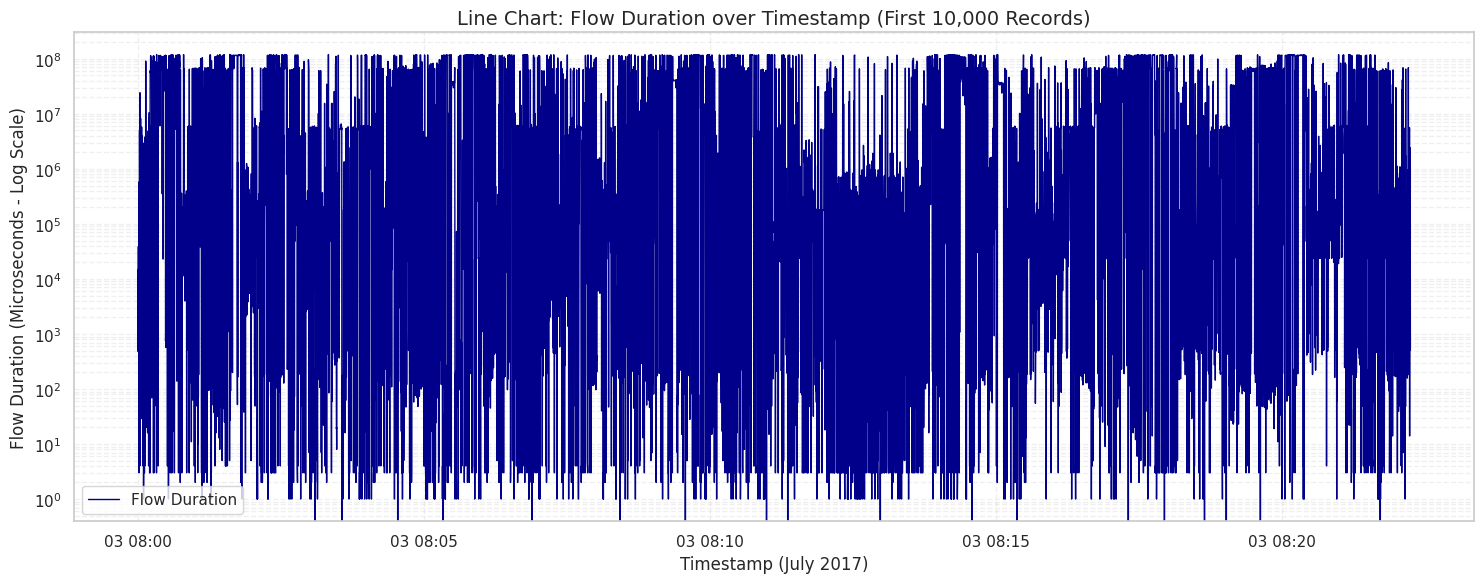

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting the first 10,000 records for clarity
df_line = df.head(10000)

plt.figure(figsize=(15, 6))

# Plotting a line chart: Timestamp on X, Flow Duration on Y
plt.plot(df_line['Timestamp'], df_line['Flow Duration'], color='darkblue', linewidth=1, label='Flow Duration')

# Using log scale for the Y-axis to handle the wide range of values
plt.yscale('log')

plt.title('Line Chart: Flow Duration over Timestamp (First 10,000 Records)', fontsize=14)
plt.xlabel('Timestamp (July 2017)', fontsize=12)
plt.ylabel('Flow Duration (Microseconds - Log Scale)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
missing_durations = df['Flow Duration'].isnull().sum()
print(f"Number of missing values in 'Flow Duration': {missing_durations}")

Number of missing values in 'Flow Duration': 0


In [ ]:
# Extract only the time part (HH:MM:SS) from the Timestamp column
df['Time'] = df['Timestamp'].dt.time

# Display the results to verify
display(df[['Timestamp', 'Time']].head())
print("New column 'Time' has been created from 'Timestamp'.")

,Timestamp,Time
0,2017-07-03 08:00:00.000000000,08:00:00
1,2017-07-03 08:00:00.133533893,08:00:00.133533
2,2017-07-03 08:00:00.267067786,08:00:00.267067
3,2017-07-03 08:00:00.400601679,08:00:00.400601
4,2017-07-03 08:00:00.534135572,08:00:00.534135


New column 'Time' has been created from 'Timestamp'.


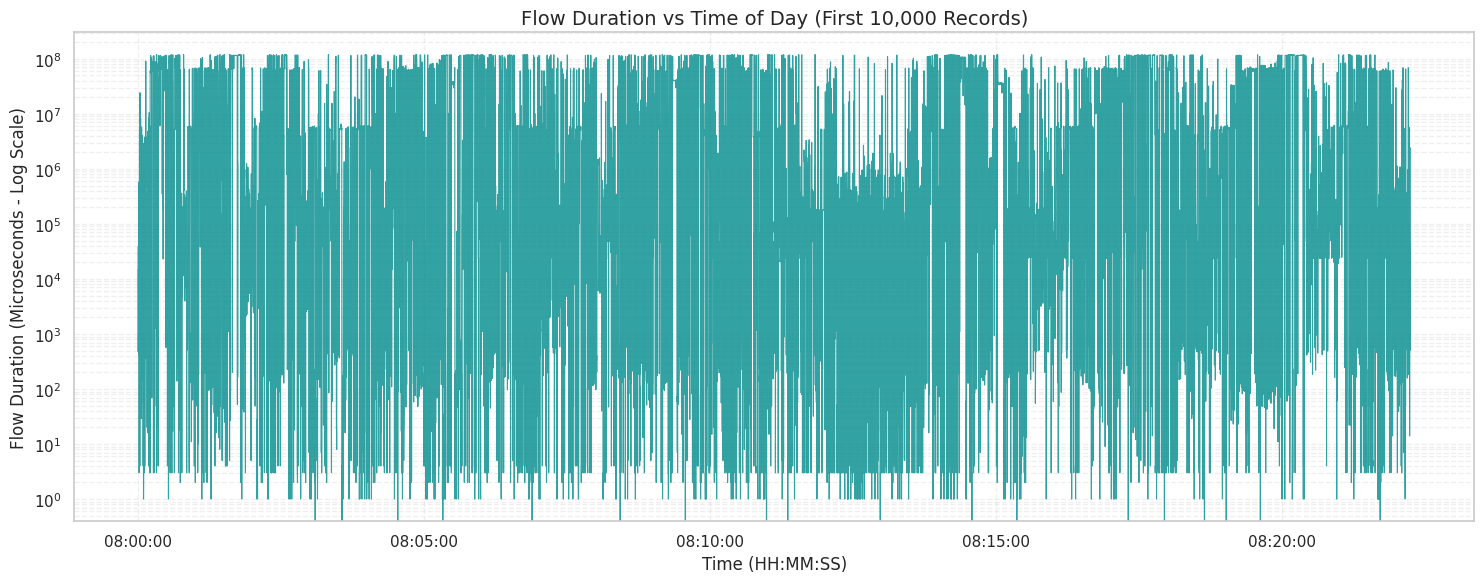

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime

# Selecting first 10,000 records
df_plot_time = df.head(10000).copy()

# To plot 'Time' objects, it's easier to use a dummy date for matplotlib
dummy_date = datetime(2017, 7, 3)
df_plot_time['time_for_plot'] = df_plot_time['Time'].apply(lambda x: datetime.combine(dummy_date, x))

plt.figure(figsize=(15, 6))
plt.plot(df_plot_time['time_for_plot'], df_plot_time['Flow Duration'], color='darkcyan', linewidth=0.8, alpha=0.8)

plt.yscale('log')

# Formatting X-axis to show HH:MM:SS
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.title('Flow Duration vs Time of Day (First 10,000 Records)', fontsize=14)
plt.xlabel('Time (HH:MM:SS)', fontsize=12)
plt.ylabel('Flow Duration (Microseconds - Log Scale)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

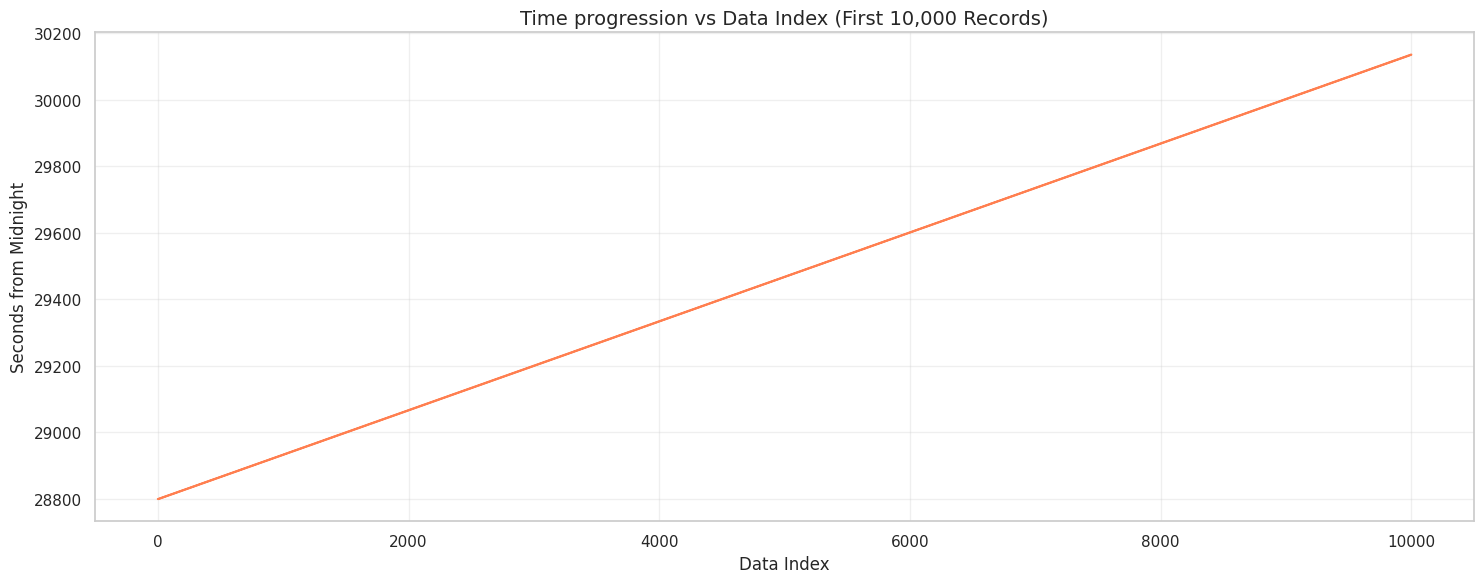

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Selecting first 10,000 records
df_index_time = df.head(10000).copy()

# Converting 'Time' to a numeric value (seconds from midnight) for easy plotting against index
df_index_time['seconds_from_midnight'] = df_index_time['Timestamp'].dt.hour * 3600 + \
                                          df_index_time['Timestamp'].dt.minute * 60 + \
                                          df_index_time['Timestamp'].dt.second

plt.figure(figsize=(15, 6))
sns.lineplot(x=df_index_time.index, y=df_index_time['seconds_from_midnight'], color='coral')

plt.title('Time progression vs Data Index (First 10,000 Records)', fontsize=14)
plt.xlabel('Data Index', fontsize=12)
plt.ylabel('Seconds from Midnight', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

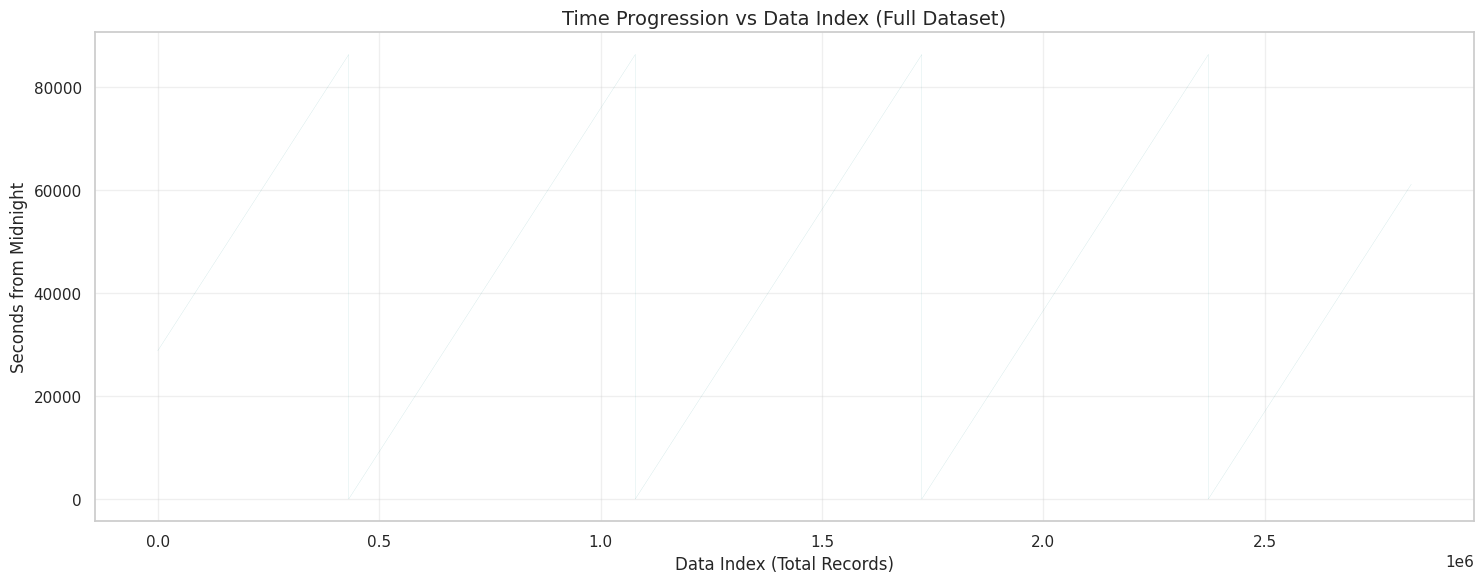

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating seconds from midnight for the entire dataframe
# This helps visualize the daily cycle (0 to 86400 seconds)
df['seconds_from_midnight_full'] = df['Timestamp'].dt.hour * 3600 + \
                                     df['Timestamp'].dt.minute * 60 + \
                                     df['Timestamp'].dt.second

plt.figure(figsize=(15, 6))
# Using a simple plot for the full dataset as it's faster than lineplot for millions of points
plt.plot(df.index, df['seconds_from_midnight_full'], color='teal', linewidth=0.1, alpha=0.5)

plt.title('Time Progression vs Data Index (Full Dataset)', fontsize=14)
plt.xlabel('Data Index (Total Records)', fontsize=12)
plt.ylabel('Seconds from Midnight', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Display the updated dataframe with the new time features
display(df.head())

# Also print the list of all current columns to confirm features
print(f"Total columns: {len(df.columns)}")
print(f"New features added: ['Timestamp', 'Time', 'seconds_from_midnight_full']")

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,time,Timestamp,Time,seconds_from_midnight_full
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038308,2017-07-03 08:00:00.000000000,08:00:00,28800
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.038787,2017-07-03 08:00:00.133533893,08:00:00.133533,28800
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.039882,2017-07-03 08:00:00.267067786,08:00:00.267067,28800
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.055088,2017-07-03 08:00:00.400601679,08:00:00.400601,28800
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0,0.0,0.0,0,0,BENIGN,0 days 00:00:00.056180,2017-07-03 08:00:00.534135572,08:00:00.534135,28800


Total columns: 83
New features added: ['Timestamp', 'Time', 'seconds_from_midnight_full']


In [ ]:
# Remove the specified columns
columns_to_drop = ['time', 'Timestamp', 'seconds_from_midnight_full']
# Use errors='ignore' in case some were already dropped in previous steps
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Display the updated dataframe
display(df.head())
print(f"Remaining columns: {len(df.columns)}")

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Time
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.133533
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.267067
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.400601
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.534135


Remaining columns: 80


In [ ]:
null_values = df.isnull().sum().sum()
display(null_values)

np.int64(1358)

In [ ]:
import pandas as pd

# Display the final state of the dataframe
display(df.head())
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Time
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.133533
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.267067
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.400601
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.534135


Total rows: 2,830,743
Total columns: 80


In [ ]:
from google.colab import files

# Save the dataframe to a csv file
output_filename = 'cleaned_network_traffic.csv'
df.to_csv(output_filename, index=False)

# Download the file to your local machine
files.download(output_filename)

print(f'File {output_filename} is being prepared for download.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File cleaned_network_traffic.csv is being prepared for download.
